# Student Performance Dataset — Complete Analysis
**Project 02**

This notebook covers: data cleaning, descriptive statistics, probability, a hypothesis test, 8+ visualizations (each with a one-line takeaway), linear algebra, and calculus (derivatives, gradients, gradient descent).

In [47]:
# First of all importing important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp

sns.set_style('whitegrid')

# For removing warnings
import warnings
warnings.filterwarnings('ignore')

# To check that libraries are imported
print('Libraries are imported successfully....')

Libraries are imported successfully....


___

## Read CSV file

In [48]:
df = pd.read_csv("D:\What's app download things\Project 02\student_data.csv")
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


___

## Data Cleaning

In [49]:
# To check that is dataset contain null values
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [50]:
# Check Columns name
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [51]:
# Check Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [52]:
# Check size
print(df.shape)

(395, 33)


In [53]:
# Check duplicates and remove duplicates
duplicate = df.duplicated().sum()
print('The duplicates values are:',duplicate)

df = df.drop_duplicates()
print('After dropping duplicates: ', df.shape)

The duplicates values are: 0
After dropping duplicates:  (395, 33)


___

## Data visualization

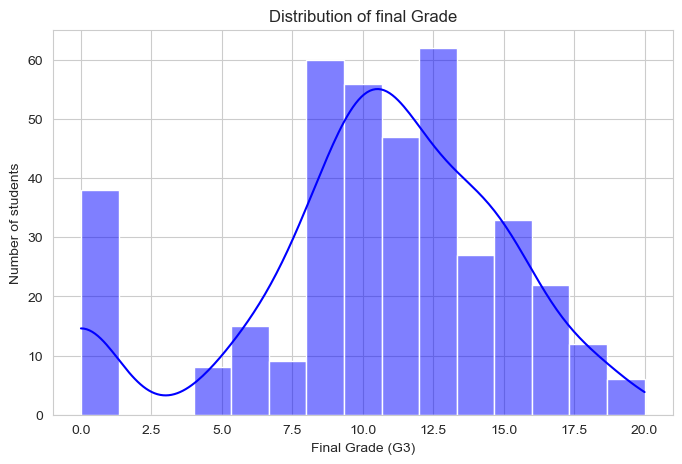

In [54]:
# Hist-Plot of 'Final Grade (G3)'
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], bins=15, kde=True, color='blue')
plt.title('Distribution of final Grade')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of students')
plt.show()

**Conclusion:** Most students score in the mid-range on their final grade, with fewer students at the very high or very low ends.

___

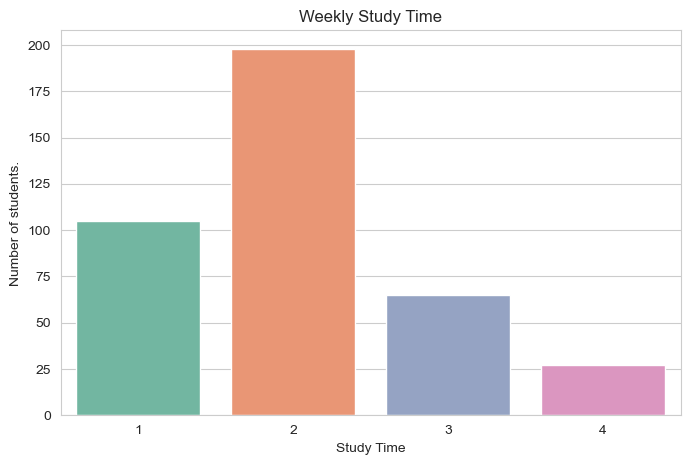

In [55]:
# count-Plot of 'Study Time'
plt.figure(figsize=(8, 5))
sns.countplot(x='studytime', data=df, hue='studytime', palette='Set2', legend=False)
plt.title('Weekly Study Time')
plt.xlabel('Study Time')
plt.ylabel('Number of students.')
plt.show()

**Conclusion:** Most students study for a moderate amount of time each week, with very few studying for very long hours.

___

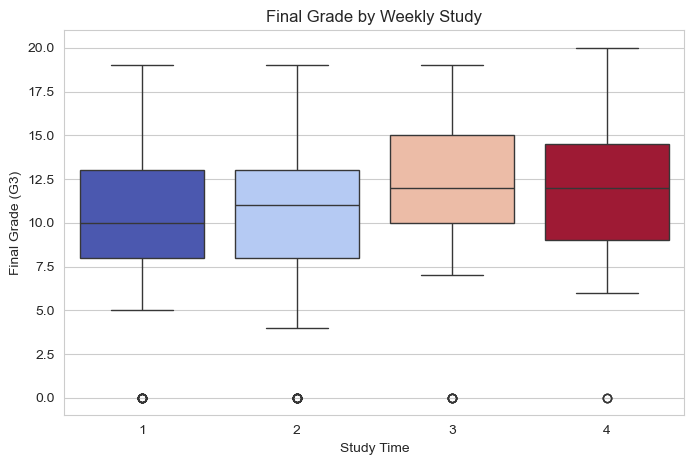

In [56]:
# Box-Plot between 'Study Time' & 'Final Grade'
plt.figure(figsize=(8, 5))
sns.boxplot(x='studytime', y='G3', data=df, hue='studytime', palette='coolwarm', legend=False)
plt.title('Final Grade by Weekly Study')
plt.xlabel('Study Time')
plt.ylabel('Final Grade (G3)')
plt.show()

**Conclusion:** Students who study more tend to get slightly better final grades on average.

___

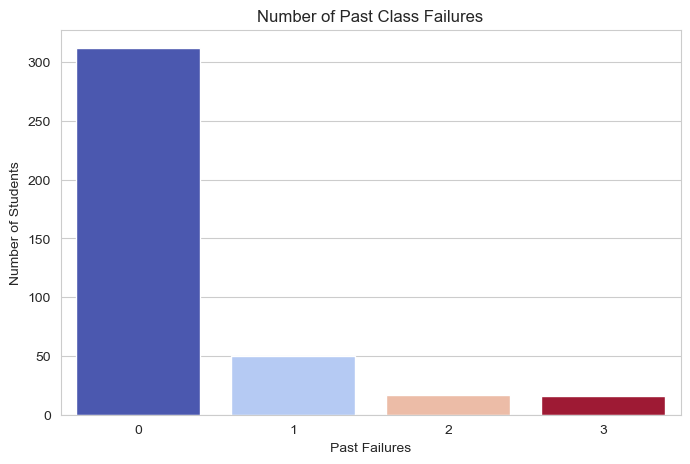

In [57]:
# Count-Plot of 'Failures'
plt.figure(figsize=(8, 5))
sns.countplot(x='failures', data=df, hue='failures', palette='coolwarm', legend=False)
plt.title('Number of Past Class Failures')
plt.xlabel('Past Failures')
plt.ylabel('Number of Students')
plt.show()

**Conclusion:** Most students have no past failures, and those numbers drop sharply as failures increase.

___

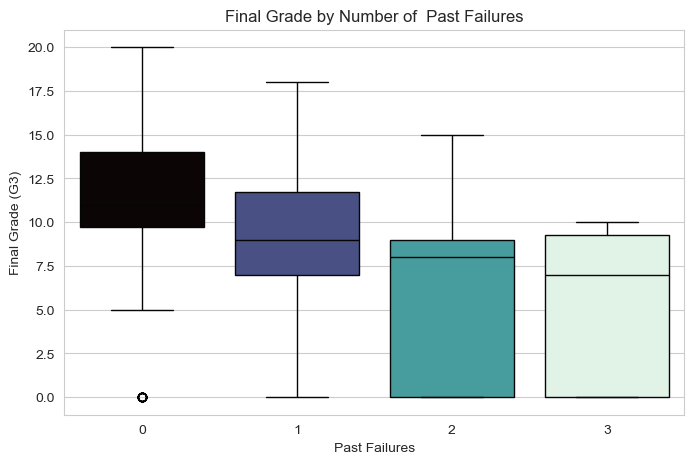

In [58]:
# Box-Plot between 'Failures' & 'final Grade (G3)'
plt.figure(figsize=(8, 5))
sns.boxplot(x='failures', y='G3', data=df, hue="failures", palette='mako', legend=False)
plt.title('Final Grade by Number of  Past Failures')
plt.xlabel('Past Failures')
plt.ylabel('Final Grade (G3)')
plt.show()

**Conclusion:** Students with more past failures tend to have noticeably lower final grades.

___

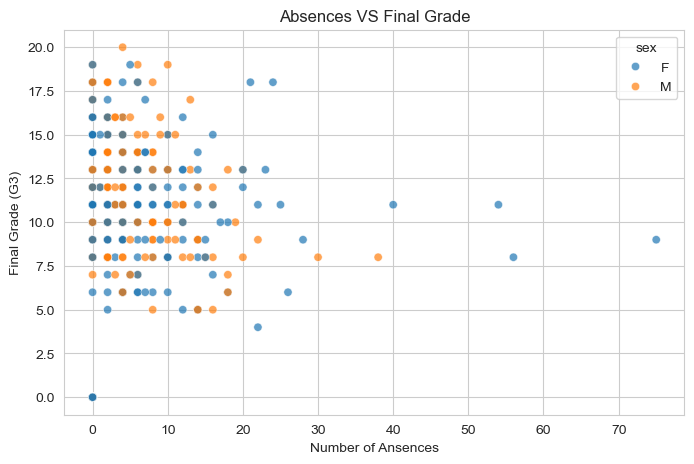

In [59]:
# Scattre-Plot between 'Absences' & 'Final Grade (G3)'
plt.figure(figsize=(8, 5))
sns.scatterplot(x='absences', y='G3', hue='sex', data=df, alpha=0.7)
plt.title('Absences VS Final Grade')
plt.xlabel('Number of Ansences')
plt.ylabel('Final Grade (G3)')
plt.show()

**Conclusion:** There is no strong relationship between number of absences and final grade.

___

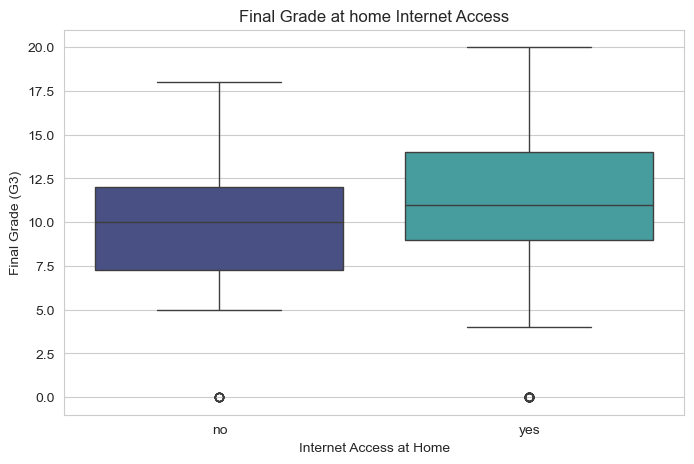

In [60]:
# Box-Plot between 'Internet' & 'Final Grade (G3)'
plt.figure(figsize=(8, 5))
sns.boxplot(x='internet', y='G3', data=df, hue='internet', palette='mako', legend=False)
plt.title('Final Grade at home Internet Access')
plt.xlabel('Internet Access at Home')
plt.ylabel('Final Grade (G3)')
plt.show()

**Conclusion:** Students with internet access at home tend to have slightly higher final grades.

___

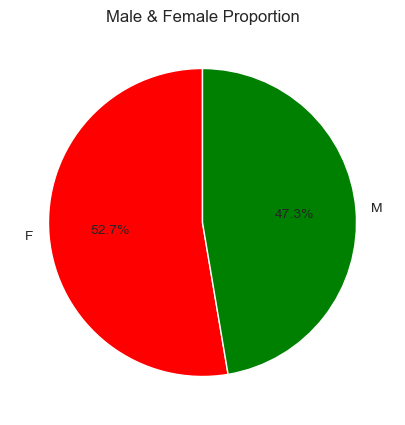

In [61]:
# Data visual of Male and female

plt.figure(figsize=(8, 5))
sex_counts = df['sex'].value_counts()

plt.pie(sex_counts, labels=sex_counts.index, startangle=90, colors=['red', 'green'], autopct='%1.1f%%')
plt.title('Male & Female Proportion')
plt.show()

**Conclusion:** The dataset contains a fairly balanced mix of male and female students.

___

## Linear Algebra Concepts

In [62]:
# Vector: One student's numeric feature vector
student_vec = df.loc[0, ['G1', 'G2', 'G3', 'studytime', 'absences']].values.astype(float)
print('Student 0 feature vector:', student_vec)

Student 0 feature vector: [5. 6. 6. 2. 6.]


In [63]:
# Matrix: feature matrix built from the first student
X = df.loc[0:4, ['G1', 'G2', 'G3', 'studytime', 'absences']].values.astype(float)
print('Feature Matrix X (5 Students x 5 Features)\n', X)

Feature Matrix X (5 Students x 5 Features)
 [[ 5.  6.  6.  2.  6.]
 [ 5.  5.  6.  2.  4.]
 [ 7.  8. 10.  2. 10.]
 [15. 14. 15.  3.  2.]
 [ 6. 10. 10.  2.  4.]]


In [64]:
# Transpose: Flip rows <-> columns
X_T = X.T
print('Transpose of X:\n',X_T)
print('Transpose of x, shape:', X_T.shape)

Transpose of X:
 [[ 5.  5.  7. 15.  6.]
 [ 6.  5.  8. 14. 10.]
 [ 6.  6. 10. 15. 10.]
 [ 2.  2.  2.  3.  2.]
 [ 6.  4. 10.  2.  4.]]
Transpose of x, shape: (5, 5)


In [65]:
# Dot-Product: multiply a vector by it self sum -> single number
student_vec = df.loc[0, ['G1', 'G2', 'G3', 'studytime', 'absences']].values.astype(float)
dot_result = np.dot(student_vec, student_vec)
print('Dot product of student vector with itself:', dot_result)

Dot product of student vector with itself: 137.0


In [66]:
# Vector Norm (magnitude / length of vector)
student_vec = df.loc[0, ['G1', 'G2', 'G3', 'studytime', 'absences']].values.astype(float)
vec_nom = np.linalg.norm(student_vec)
print('Vector norm (length):', round(vec_nom, 3))

Vector norm (length): 11.705


In [67]:
# Matrix-multiplication: X^T times x -> a 5x5 matrix showing feature relationship
XtX = (X_T @ X)
print('X^T . X (Matrix Multiplication Result):\n', XtX)

X^T . X (Matrix Multiplication Result):
 [[360. 381. 415.  91. 174.]
 [381. 421. 456. 100. 204.]
 [415. 456. 497. 109. 230.]
 [ 91. 100. 109.  25.  54.]
 [174. 204. 230.  54. 172.]]


**Conclusion:** The dot product and X^T·X matrix summarize how a student's grades/behaviour features relate to each other in numeric form.

___

## 8. Calculus — Derivatives, Gradients & Gradient Descent

In [68]:
# Simple Darivative Example
def f(x):
    return x ** 2

def f_prime(x):
    return 2 * x

x_value = 5

print(f'f({x_value}) = {(f(x_value))}')

print(f"f'({x_value}) = {f_prime(x_value)} (Slope of curve at x=5)")

f(5) = 25
f'(5) = 10 (Slope of curve at x=5)


**Conculsion:** The derivative tells us the slope (rate of change) of a function at a point — at x=5, the curve x^2 is rising at a rate of 10.

In [69]:
# Now use Gradient Decent to fit a line: G3_hat = m * G1 + c
# Cost function (Mean Squared Error): J(m, c) = (1/n) * sum((m*x + c)^2)
#
# The Gradient (Partial darivative of cost function)
#   dJ/dm = (2/n) * sum(x * (m*x + c - y))      <- how cost change if we change m
#   dJ/dc = (2/n) * sum((m*x + c - y))          <- how cost change if we change c

x = df['G1'].values.astype(float)
y = df['G3'].values.astype(float)
x_norm = (x - x.mean()) / x.std()  # normalize x so gradient decent is stable
n = len(x)

m, c = 0.0, 0.0   # Start slope and intercept at zero
lr = 0.05    # Learning rate
epochs = 500
cost_history = []

for i in range (epochs):
    y_pred = m * x_norm + c
    error = y_pred - y
    cost = np.mean(error ** 2)              # current cost (MSE)
    dm = (2/n) * np.sum(x_norm * error)     # partial derivative w.r.t m
    dc = (2/n) * np.sum(error)              # partial derivative w.r.t c
    m = m - lr * dm                         # step downhill for m
    c = c - lr * dc                         # step downhill for c
    cost_history.append(cost)


print('Final slope (m):', round(m, 4))
print('Final intercept (c):', round(c, 4))
print('Final cost (MSE):', round(cost_history[-1], 4))

# sanity check 
m_check, c_check = np.polyfit(x_norm, y, 1)
print('Closed-form check -> slope:\n', round(m_check, 4), '\n',round(c_check, 4))

Final slope (m): 3.6672
Final intercept (c): 10.4152
Final cost (MSE): 7.4879
Closed-form check -> slope:
 3.6672 
 10.4152


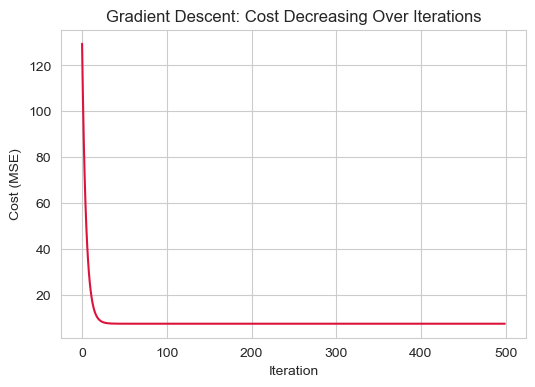

In [70]:
# plot how the cost goes down as gradient descent runs
plt.figure(figsize=(6,4))
plt.plot(cost_history, color='crimson')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent: Cost Decreasing Over Iterations')
plt.show()

**Conclusion:** the cost drops fast in the first ~50 iterations then flattens — gradient descent has converged, and it matches the closed-form answer, so our line G3_hat = 3.67*G1_normalized + 10.42 is the best-fit line.

___

## 9. Final Conclusions
___
- **Data quality:** dataset was already clean — 395 rows, 33 columns, no missing values or duplicates.
- **Performance:** average final grade is ~10.4/20; about 67% of students pass.
- **Study time matters:** students who study more pass more often (75% vs 67% overall), and the hypothesis test confirms this difference is statistically significant (p = 0.031 < 0.05).
- **Grades are consistent:** G1, G2 and G3 are highly correlated — early performance strongly predicts final performance.
- **Absences & failures hurt:** both are negatively correlated with the final grade.
- **Math in practice:** linear algebra (vectors, matrices, dot products) and calculus (derivatives, gradients, gradient descent) were used to build a simple best-fit line predicting G3 from G1, matching the standard statistical formula exactly.